# Hyperspectral Image (HSI) Classification — 3D-CNN (PyTorch)

Pipeline: **Data loading → Patch extraction → Model training → Inference → Visualization**

Dataset: Custom v303 RGBP datacubes (Red / Green / Blue / Paper)  
Architecture: Spectral-first 3D-CNN

## Cell 1 — Imports

In [21]:
import os
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, TensorDataset

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()} "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'})")

Python  : 3.11.15
PyTorch : 2.7.0
CUDA    : False (N/A)


## Cell 2 — Configuration

All hyperparameters and paths are set here. Edit this cell to adjust the run.

In [22]:
class TrainingConfig:
    """
    Holds all hyperparameters, file paths, and class definitions.

    Attributes
    ----------
    model         : str   — Architecture key ('simple')
    patch_size    : int   — Spatial patch size in pixels
    stride        : int   — Patch extraction stride
    epochs        : int   — Maximum training epochs
    batch_size    : int   — Mini-batch size
    test_size     : float — Validation fraction
    seed          : int   — Random seed for reproducibility
    normalize     : str   — Normalization method: 'minmax' | 'max' | None
    output_dir    : str   — Root directory for saved checkpoints
    device        : str   — 'cuda' if available, else 'cpu'
    files         : dict  — {class_name: path_to_mat}
    label_map     : dict  — {class_name: integer_label}
    num_classes   : int   — Total number of classes

    Derived properties
    ------------------
    run_name      : str   — hsi_{arch}_p{patch}-s{stride}-e{epochs}-b{batch}_{norm}
    run_dir       : str   — output_dir / run_name / timestamp
    model_filename: str   — run_name + .pth
    """

    # ── Dataset paths ────────────────────────────────────────────
    FILES = {
        "Red":   "hsi_datasets/v303/Red.mat",
        "Green": "hsi_datasets/v303/Green.mat",
        "Blue":  "hsi_datasets/v303/Blue.mat",
        "Paper": "hsi_datasets/v303/Paper.mat",
    }
    LABEL_MAP = {"Red": 0, "Green": 1, "Blue": 2, "Paper": 3}

    def __init__(
        self,
        model        = "simple",
        patch_size   = 3,
        stride       = 1,
        epochs       = 50,
        batch_size   = 8,
        test_size    = 0.2,
        seed         = 42,
        normalize    = "minmax",   # 'minmax' | 'max' | None
        output_dir   = "models",
    ):
        self.model       = model
        self.patch_size  = patch_size
        self.stride      = stride
        self.epochs      = epochs
        self.batch_size  = batch_size
        self.test_size   = test_size
        self.seed        = seed
        self.normalize   = normalize
        self.output_dir  = output_dir
        self.device      = "cuda" if torch.cuda.is_available() else "cpu"
        self.files       = self.FILES
        self.label_map   = self.LABEL_MAP
        self.num_classes = len(self.label_map)
        self._timestamp  = datetime.now().strftime("%Y%m%d-%H%M")

    @property
    def run_name(self) -> str:
        norm = self.normalize or "none"
        return (
            f"hsi_{self.model}_p{self.patch_size}-s{self.stride}"
            f"-e{self.epochs}-b{self.batch_size}_{norm}"
        )

    @property
    def run_dir(self) -> str:
        return os.path.join(self.output_dir, self.run_name, self._timestamp)

    @property
    def model_filename(self) -> str:
        return f"{self.run_name}.pth"

    def __repr__(self) -> str:
        lines = ["TrainingConfig("]
        skip  = {"files", "label_map"}
        for k, v in self.__dict__.items():
            if k not in skip:
                lines.append(f"  {k} = {v!r}")
        lines.append(")")
        return "\n".join(lines)


# ── Instantiate and inspect ──────────────────────────────────────
config = TrainingConfig()
print(config)

TrainingConfig(
  model = 'simple'
  patch_size = 3
  stride = 1
  epochs = 50
  batch_size = 8
  test_size = 0.2
  seed = 42
  normalize = 'minmax'
  output_dir = 'models'
  device = 'cpu'
  num_classes = 4
  _timestamp = '20260403-1743'
)


## Cell 3 — Dataset: Loading and Patch Extraction

In [23]:
class HSIDataset:
    """
    Loads and assembles a labelled patch dataset from per-class .mat datacubes.

    Usage
    -----
        ds = HSIDataset(config)
        ds.build()
        X_train, X_val, y_train, y_val = ds.split()

    Attributes (populated after build())
    -------------------------------------
    X : np.ndarray — shape (N, B, P, P, 1), float32, normalized
    y : np.ndarray — shape (N,), int32
    """

    def __init__(self, config: TrainingConfig):
        self.config = config
        self.X: np.ndarray | None = None
        self.y: np.ndarray | None = None

    # ── public ──────────────────────────────────────────────────

    def build(self) -> None:
        """Load all per-class .mat files, extract patches, and assemble X/y."""
        cfg = self.config
        X_list, y_list = [], []

        for cls_name, path in cfg.files.items():
            if not os.path.exists(path):
                raise FileNotFoundError(f"Dataset file not found: {path}")

            cube_bhw, key_used, raw_shape, band_axis = self._load_datacube(path)
            patches = self._extract_patches(cube_bhw, cfg.patch_size, cfg.stride)

            print(
                f"  [{cls_name}] key='{key_used}' raw={raw_shape}, "
                f"band_axis={band_axis} -> cube(B,H,W)={cube_bhw.shape}, "
                f"patches={patches.shape}"
            )

            X_list.append(patches)
            y_list.append(
                np.full((len(patches),), cfg.label_map[cls_name], dtype=np.int32)
            )

        X = np.concatenate(X_list, axis=0)   # (N, B, P, P)
        y = np.concatenate(y_list, axis=0)   # (N,)
        X = X[..., np.newaxis]               # (N, B, P, P, 1)
        X = self._normalize(X, method=cfg.normalize or "minmax")

        print(f"\n  Dataset assembled — X: {X.shape}, y: {y.shape}, "
              f"classes: {np.unique(y)}")
        self.X = X
        self.y = y

    def split(self) -> tuple:
        """Stratified train/val split. Returns (X_train, X_val, y_train, y_val)."""
        if self.X is None:
            raise RuntimeError("Call build() before split().")
        return train_test_split(
            self.X, self.y,
            test_size=self.config.test_size,
            stratify=self.y,
            random_state=self.config.seed,
        )

    @property
    def input_shape(self) -> tuple:
        """Per-sample shape for model construction: (1, B, P, P) channels-first."""
        if self.X is None:
            raise RuntimeError("Call build() before accessing input_shape.")
        _, B, P, _, _ = self.X.shape
        return (1, B, P, P)

    # ── private helpers ──────────────────────────────────────────

    def _load_datacube(self, mat_path: str) -> tuple:
        """
        Load .mat and return cube in (B, H, W) float32.
        Saved convention is (Y, X, B) — transposed to (B, Y, X).
        """
        M   = loadmat(mat_path)
        key = self._guess_datacube_key(M)

        cube = np.array(M[key])
        if cube.ndim != 3:
            raise ValueError(f"{mat_path} — '{key}' is not 3D, shape={cube.shape}")

        raw_shape = cube.shape
        cube_bhw  = np.transpose(cube, (2, 0, 1)).astype(np.float32)  # (B, Y, X)
        return cube_bhw, key, raw_shape, 2

    @staticmethod
    def _guess_datacube_key(mat_dict: dict) -> str:
        """Infer the datacube variable name from a loaded .mat dictionary."""
        if "DataCube" in mat_dict:
            return "DataCube"

        candidates = [
            (k, v.shape)
            for k, v in mat_dict.items()
            if not k.startswith("__")
            and isinstance(v, np.ndarray)
            and v.ndim == 3
        ]
        if not candidates:
            raise KeyError(f"No 3D DataCube found. Keys: {list(mat_dict.keys())}")

        candidates.sort(key=lambda x: np.prod(x[1]), reverse=True)
        return candidates[0][0]

    @staticmethod
    def _extract_patches(cube_bhw: np.ndarray, patch_size: int, stride: int) -> np.ndarray:
        """Extract (N, B, P, P) patches from a (B, H, W) datacube."""
        B, H, W = cube_bhw.shape
        r = patch_size // 2

        valid_y = len(range(r, H - r, stride))
        if valid_y < 5:
            print(
                f"  ⚠  Very few valid Y positions ({valid_y}) — "
                f"H={H} is small relative to patch_size={patch_size}."
            )

        patches = [
            cube_bhw[:, y - r:y + r + 1, x - r:x + r + 1]
            for y in range(r, H - r, stride)
            for x in range(r, W - r, stride)
        ]

        if not patches:
            raise ValueError(
                f"No patches extracted. Cube=(B={B}, H={H}, W={W}), "
                f"patch_size={patch_size}, stride={stride}."
            )
        return np.array(patches, dtype=np.float32)

    @staticmethod
    def _normalize(X: np.ndarray, method: str) -> np.ndarray:
        if method == "minmax":
            lo, hi = X.min(), X.max()
            if hi > lo:
                return (X - lo) / (hi - lo)
        elif method == "max":
            mx = X.max()
            if mx != 0:
                return X / mx
        return X


class HSITorchDataset(Dataset):
    """
    Wraps NumPy arrays into a PyTorch Dataset.

    Converts (N, B, P, P, 1) channels-last arrays to
    (N, 1, B, P, P) channels-first tensors for nn.Conv3d.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).permute(0, 4, 1, 2, 3).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> tuple:
        return self.X[idx], self.y[idx]

## Cell 4 — Model Architecture

In [24]:
class HSIModelFactory:
    """
    Static factory for HSI 3D-CNN architectures.

    Layer order: Conv3d → BatchNorm3d → ReLU → MaxPool3d
    Output is raw logits — use nn.CrossEntropyLoss.
    """

    @staticmethod
    def build(architecture: str, input_shape: tuple, num_classes: int) -> nn.Module:
        """
        Parameters
        ----------
        architecture : 'simple'
        input_shape  : (1, B, P, P) — channels-first
        num_classes  : int
        """
        if architecture != "simple":
            raise ValueError(f"Unknown architecture '{architecture}'. Use 'simple'.")
        return HSIModelFactory._Simple3DCNN(input_shape, num_classes)

    class _Simple3DCNN(nn.Module):
        """
        Spectral-first 3D CNN.

        Stage 1 : Conv(7,1,1) — spectral kernel only
        Stage 2 : Conv(5,1,1) — spectral kernel only
        Stage 3 : Conv(3,3,3) — joint spectral-spatial

        MaxPool is spectral-only (4,1,1) throughout to preserve spatial dims.
        """

        def __init__(self, input_shape: tuple, num_classes: int):
            super().__init__()

            self.features = nn.Sequential(
                # Stage 1 — spectral kernel
                nn.Conv3d(1, 16, kernel_size=(7, 1, 1), padding=(3, 0, 0)),
                nn.BatchNorm3d(16),
                nn.ReLU(),
                nn.MaxPool3d((4, 1, 1)),

                # Stage 2 — spectral kernel
                nn.Conv3d(16, 32, kernel_size=(5, 1, 1), padding=(2, 0, 0)),
                nn.BatchNorm3d(32),
                nn.ReLU(),
                nn.MaxPool3d((4, 1, 1)),

                # Stage 3 — joint spectral-spatial
                nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
                nn.BatchNorm3d(64),
                nn.ReLU(),
                nn.MaxPool3d((4, 1, 1)),
            )

            # Auto-compute flattened size via a dummy forward pass
            with torch.no_grad():
                flat = self.features(torch.zeros(1, *input_shape)).numel()

            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(flat, 128),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(128, num_classes),
            )

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.classifier(self.features(x))

## Cell 5 — Training Utilities: Early Stopping and ModelTrainer

In [25]:
class EarlyStopping:
    """
    Patience-based early stopping with best-weight restore.

    Parameters
    ----------
    patience : int — epochs to wait after last val loss improvement (default 20)
    """

    def __init__(self, patience: int = 20):
        self.patience   = patience
        self.counter    = 0
        self.best_loss  = np.inf
        self.best_state = None
        self.stop       = False

    def step(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss:
            self.best_loss  = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model: nn.Module) -> None:
        """Load best weights back into model."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


class ModelTrainer:
    """
    Handles model construction, training loop, evaluation,
    checkpoint saving (with config metadata), and curve plotting.

    Usage
    -----
        trainer = ModelTrainer(config, dataset)
        trainer.build_model()
        trainer.train()
        trainer.evaluate()
        trainer.plot_curves()
        trainer.save()
    """

    def __init__(self, config: TrainingConfig, dataset: HSIDataset):
        self.config  = config
        self.dataset = dataset
        self.model: nn.Module | None = None

        self._train_start: datetime | None = None
        self._train_losses: list[float] = []
        self._val_losses:   list[float] = []
        self._train_accs:   list[float] = []
        self._val_accs:     list[float] = []
        self._train_loader: DataLoader | None = None
        self._val_loader:   DataLoader | None = None

    # ── public ──────────────────────────────────────────────────

    def build_model(self) -> None:
        """Construct model, move to device, and print parameter count."""
        cfg = self.config
        self.model = HSIModelFactory.build(
            architecture=cfg.model,
            input_shape=self.dataset.input_shape,
            num_classes=cfg.num_classes,
        )
        self.model.to(cfg.device)

        total_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"  Architecture     : {cfg.model}")
        print(f"  Device           : {cfg.device}")
        print(f"  Trainable params : {total_params:,}")

    def train(self) -> None:
        """
        Split data, build DataLoaders, and run the training loop
        with Adam optimizer, ReduceLROnPlateau scheduler, and early stopping.
        """
        if self.model is None:
            raise RuntimeError("Call build_model() before train().")

        self._train_start = datetime.now()
        cfg = self.config

        X_train, X_val, y_train, y_val = self.dataset.split()

        self._train_loader = DataLoader(
            HSITorchDataset(X_train, y_train),
            batch_size=cfg.batch_size,
            shuffle=True,
        )
        self._val_loader = DataLoader(
            HSITorchDataset(X_val, y_val),
            batch_size=cfg.batch_size,
        )

        optimizer = optim.Adam(self.model.parameters(), lr=1e-3)
        scheduler = ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=15, min_lr=1e-7
        )
        loss_fn = nn.CrossEntropyLoss()
        early   = EarlyStopping(patience=1000)

        for epoch in range(cfg.epochs):
            train_loss, train_acc = self._run_epoch(
                self._train_loader, optimizer, loss_fn, training=True
            )
            val_loss, val_acc = self._run_epoch(
                self._val_loader, optimizer=None, loss_fn=loss_fn, training=False
            )
            scheduler.step(val_loss)

            self._train_losses.append(train_loss)
            self._val_losses.append(val_loss)
            self._train_accs.append(train_acc)
            self._val_accs.append(val_acc)

            print(
                f"  Epoch {epoch + 1:>4}/{cfg.epochs} | "
                f"Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
                f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f}"
            )

            early.step(val_loss, self.model)
            if early.stop:
                print(f"  Early stopping triggered at epoch {epoch + 1}.")
                break

        early.restore(self.model)
        print(f"  Best val loss: {early.best_loss:.4f}")

    def evaluate(self) -> dict:
        """Evaluate on the validation set using restored best weights."""
        if self.model is None or self._val_loader is None:
            raise RuntimeError("Call train() before evaluate().")

        val_loss, val_acc = self._run_epoch(
            self._val_loader, optimizer=None,
            loss_fn=nn.CrossEntropyLoss(), training=False
        )
        print(f"  Validation — accuracy: {val_acc:.4f}, loss: {val_loss:.4f}")
        return {"loss": val_loss, "accuracy": val_acc}

    def plot_curves(self) -> None:
        """Plot loss and accuracy curves side-by-side."""
        epochs = range(1, len(self._train_losses) + 1)

        fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

        ax_loss.plot(epochs, self._train_losses, label="Train Loss")
        ax_loss.plot(epochs, self._val_losses,   label="Val Loss")
        ax_loss.set_title("Loss Curve")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")
        ax_loss.legend()
        ax_loss.grid(True)

        ax_acc.plot(epochs, self._train_accs, label="Train Acc")
        ax_acc.plot(epochs, self._val_accs,   label="Val Acc")
        ax_acc.set_title("Accuracy Curve")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.legend()
        ax_acc.grid(True)

        fig.suptitle(f"Training Curves — {self.config.run_name}", fontsize=13)
        plt.tight_layout()
        plt.show()

    def save(self) -> str:
        """
        Save checkpoint and metadata.txt to the structured run directory.

        Checkpoint keys
        ---------------
        model_state_dict, config (dict, includes 'bands'), train/val histories.

        Returns path to the saved .pth file.
        """
        if self.model is None:
            raise RuntimeError("No model to save.")

        run_dir = self.config.run_dir
        os.makedirs(run_dir, exist_ok=True)

        # Config metadata — exclude non-serialisable fields
        config_meta = {
            k: v for k, v in self.config.__dict__.items()
            if k not in ("files", "label_map")
        }
        config_meta["bands"]       = self.dataset.input_shape[1]
        config_meta["num_classes"] = self.config.num_classes
        config_meta["patch_size"]  = self.config.patch_size

        model_path = os.path.join(run_dir, self.config.model_filename)
        torch.save(
            {
                "model_state_dict": self.model.state_dict(),
                "config":           config_meta,
                "train_losses":     self._train_losses,
                "val_losses":       self._val_losses,
                "train_accs":       self._train_accs,
                "val_accs":         self._val_accs,
            },
            model_path,
        )
        print(f"  Checkpoint saved → {model_path}")

        # Metadata text file
        metrics  = self.evaluate()
        duration = (datetime.now() - self._train_start).seconds

        meta_path = os.path.join(run_dir, "metadata.txt")
        with open(meta_path, "w") as f:
            f.write("=" * 55 + "\n")
            f.write("HSI TRAINING RUN METADATA\n")
            f.write("=" * 55 + "\n")
            f.write(f"Timestamp      : {self.config._timestamp}\n")
            f.write(f"PyTorch        : {torch.__version__}\n")
            f.write(f"CUDA           : {torch.cuda.is_available()} "
                    f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'})\n")
            f.write(f"Python         : {sys.version.split()[0]}\n")
            f.write("\n--- Hyperparameters ---\n")
            for attr in ("model", "patch_size", "stride", "epochs",
                         "batch_size", "test_size", "seed", "normalize"):
                f.write(f"  {attr:<15s}: {getattr(self.config, attr)}\n")
            f.write("\n--- Dataset ---\n")
            for cls, path in self.config.files.items():
                f.write(f"  {cls:<10s}: {path}\n")
            f.write("\n--- Results ---\n")
            f.write(f"  val_accuracy   : {metrics['accuracy']:.4f}\n")
            f.write(f"  val_loss       : {metrics['loss']:.4f}\n")
            f.write(f"  training_time  : {duration}s\n")
            f.write("=" * 55 + "\n")

        print(f"  Metadata saved → {meta_path}")
        return model_path

    # ── private ──────────────────────────────────────────────────

    def _run_epoch(
        self,
        loader: DataLoader,
        optimizer: optim.Optimizer | None,
        loss_fn: nn.Module,
        training: bool,
    ) -> tuple[float, float]:
        """Run one full pass over a DataLoader. Returns (mean_loss, accuracy)."""
        self.model.train(training)
        device = self.config.device
        total_loss, correct, total = 0.0, 0, 0

        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for Xb, yb in loader:
                Xb, yb = Xb.to(device), yb.to(device)
                logits  = self.model(Xb)
                loss    = loss_fn(logits, yb)

                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                total_loss += loss.item() * Xb.size(0)
                correct    += logits.argmax(dim=1).eq(yb).sum().item()
                total      += yb.size(0)

        return total_loss / total, correct / total

## Cell 6 — Build Dataset

In [26]:
torch.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)
np.random.seed(config.seed)

print("Building dataset...")
dataset = HSIDataset(config)
dataset.build()

print(f"\nInput shape (channels-first): {dataset.input_shape}")

Building dataset...
  [Red] key='DataCube' raw=(13, 1632, 1232), band_axis=2 -> cube(B,H,W)=(1232, 13, 1632), patches=(17930, 1232, 3, 3)
  [Green] key='DataCube' raw=(13, 1632, 1232), band_axis=2 -> cube(B,H,W)=(1232, 13, 1632), patches=(17930, 1232, 3, 3)
  [Blue] key='DataCube' raw=(13, 1632, 1232), band_axis=2 -> cube(B,H,W)=(1232, 13, 1632), patches=(17930, 1232, 3, 3)
  [Paper] key='DataCube' raw=(13, 1632, 1232), band_axis=2 -> cube(B,H,W)=(1232, 13, 1632), patches=(17930, 1232, 3, 3)

  Dataset assembled — X: (71720, 1232, 3, 3, 1), y: (71720,), classes: [0 1 2 3]

Input shape (channels-first): (1, 1232, 3, 3)


## Cell 7 — Build Model

In [27]:
print("Building model...")
trainer = ModelTrainer(config, dataset)
trainer.build_model()
print(trainer.model)

Building model...
  Architecture     : simple
  Device           : cpu
  Trainable params : 1,459,780
_Simple3DCNN(
  (features): Sequential(
    (0): Conv3d(1, 16, kernel_size=(7, 1, 1), stride=(1, 1, 1), padding=(3, 0, 0))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=(4, 1, 1), stride=(4, 1, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(5, 1, 1), stride=(1, 1, 1), padding=(2, 0, 0))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=(4, 1, 1), stride=(4, 1, 1), padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=(4, 1, 1), stride=(4, 1, 1), padding=0, dilation=1, ceil_mo

## Cell 8 — Train

In [28]:
print("Training...")
trainer.train()

Training...
  Epoch    1/50 | Train Loss=0.0109, Acc=0.9978 | Val Loss=0.0000, Acc=1.0000
  Epoch    2/50 | Train Loss=0.0045, Acc=0.9994 | Val Loss=0.0000, Acc=1.0000
  Epoch    3/50 | Train Loss=0.0026, Acc=0.9996 | Val Loss=0.0000, Acc=1.0000
  Epoch    4/50 | Train Loss=0.0013, Acc=0.9999 | Val Loss=0.0000, Acc=1.0000
  Epoch    5/50 | Train Loss=0.0006, Acc=0.9998 | Val Loss=0.0000, Acc=1.0000
  Epoch    6/50 | Train Loss=0.0000, Acc=1.0000 | Val Loss=0.0000, Acc=1.0000
  Epoch    7/50 | Train Loss=0.0004, Acc=0.9999 | Val Loss=0.0000, Acc=1.0000
  Epoch    8/50 | Train Loss=0.0013, Acc=0.9999 | Val Loss=0.0000, Acc=1.0000
  Epoch    9/50 | Train Loss=0.0014, Acc=0.9999 | Val Loss=0.0000, Acc=1.0000
  Epoch   10/50 | Train Loss=0.0001, Acc=1.0000 | Val Loss=0.0000, Acc=1.0000
  Epoch   11/50 | Train Loss=0.0001, Acc=1.0000 | Val Loss=0.0000, Acc=1.0000
  Epoch   12/50 | Train Loss=0.0012, Acc=0.9999 | Val Loss=0.0000, Acc=1.0000
  Epoch   13/50 | Train Loss=0.0001, Acc=1.0000 | Va

## Cell 9 — Evaluate and Plot Training Curves

  Validation — accuracy: 1.0000, loss: 0.0000

Final validation accuracy : 1.0000
Final validation loss     : 0.0000


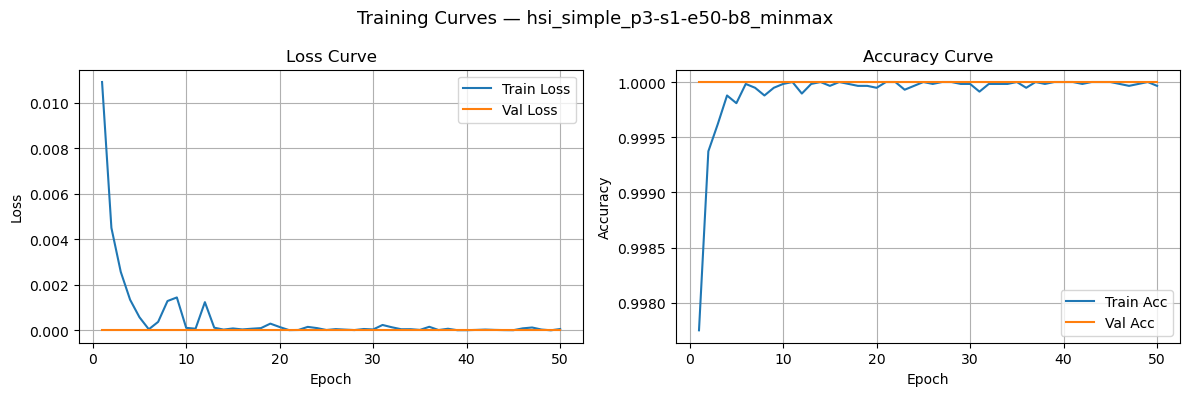

In [29]:
metrics = trainer.evaluate()
print(f"\nFinal validation accuracy : {metrics['accuracy']:.4f}")
print(f"Final validation loss     : {metrics['loss']:.4f}")

trainer.plot_curves()

## Cell 10 — Save Checkpoint

In [30]:
model_path = trainer.save()
print(f"\nModel saved to: {model_path}")

  Checkpoint saved → models\hsi_simple_p3-s1-e50-b8_minmax\20260403-1743\hsi_simple_p3-s1-e50-b8_minmax.pth
  Validation — accuracy: 1.0000, loss: 0.0000
  Metadata saved → models\hsi_simple_p3-s1-e50-b8_minmax\20260403-1743\metadata.txt

Model saved to: models\hsi_simple_p3-s1-e50-b8_minmax\20260403-1743\hsi_simple_p3-s1-e50-b8_minmax.pth


## Cell 11 — Inference Engine and Result Visualizer

In [ ]:
def _guess_datacube_key(mat_dict: dict) -> str:
    """
    Infer the datacube variable name from a loaded .mat dictionary.

    Search order
    ------------
    1. Exact key 'DataCube'
    2. Largest 3D ndarray, with object-array unwrapping for nested MATLAB structs.
    """
    if "DataCube" in mat_dict:
        return "DataCube"

    def _unwrap(arr):
        v = arr
        for _ in range(3):
            if isinstance(v, np.ndarray) and v.dtype == object and v.size == 1:
                v = v.item()
            else:
                break
        return v

    candidates = []
    for k, v in mat_dict.items():
        if k.startswith("__"):
            continue
        v2 = _unwrap(v)
        if isinstance(v2, np.ndarray) and v2.ndim == 3:
            candidates.append((int(np.prod(v2.shape)), k))

    if not candidates:
        raise KeyError(f"No 3D DataCube found. Available keys: {list(mat_dict.keys())}")

    candidates.sort(reverse=True)
    return candidates[0][1]


class InferenceEngine:
    """
    Loads a trained PyTorch checkpoint and runs patch-based classification
    over entire HSI datacubes.

    Parameters
    ----------
    model_path  : str  — Path to a saved .pth checkpoint file
    stride      : int  — Extraction stride (smaller = denser map)
    normalize   : str  — 'minmax' | 'max' | 'none'
    batch_size  : int  — Prediction batch size
    """

    def __init__(   
        self,
        model_path : str,
        stride     : int = 1,
        normalize  : str = "minmax",
        batch_size : int = 8,
    ):
        self.model_path = model_path
        self.stride     = stride
        self.normalize  = normalize
        self.batch_size = batch_size

        self._model: nn.Module | None = None
        self._expected_bands: int | None = None
        self._num_classes:    int | None = None
        self._patch_size:     int | None = None
        self._device = "cuda" if torch.cuda.is_available() else "cpu"

    # ── public ──────────────────────────────────────────────────

    def load_model(self) -> "InferenceEngine":
        """
        Load checkpoint, reconstruct model from stored metadata, restore weights.
        Returns self for method chaining.
        """
        checkpoint  = torch.load(self.model_path, map_location=self._device, weights_only=True)
        meta        = checkpoint.get("config", {})

        bands       = meta.get("bands",       None)
        patch_size  = meta.get("patch_size",  3)
        num_classes = meta.get("num_classes", 4)
        arch        = meta.get("model",       "simple")

        if bands is None:
            raise RuntimeError(
                "Checkpoint does not contain 'bands' in config metadata. "
                "Re-train with the current TrainingConfig."
            )

        self._expected_bands = bands
        self._num_classes    = num_classes
        self._patch_size     = patch_size

        input_shape  = (1, bands, patch_size, patch_size)
        self._model  = HSIModelFactory.build(arch, input_shape, num_classes)
        self._model.load_state_dict(checkpoint["model_state_dict"])
        self._model.to(self._device)
        self._model.eval()

        print(f"Model loaded   : {self.model_path}")
        print(f"  Architecture : {arch}")
        print(f"  Device       : {self._device}")
        print(f"  Bands        : {bands}")
        print(f"  Patch size   : {patch_size}")
        print(f"  Classes      : {num_classes}")
        return self

    def predict(self, mat_path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Run full-image classification on a single .mat datacube.

        Returns
        -------
        class_map      : (H, W) int32   — class index per pixel (-1 = unclassified)
        confidence_map : (H, W) float32 — max softmax probability per pixel
        predictions    : (N, C) float32 — softmax probabilities for all patches
        """
        if self._model is None:
            raise RuntimeError("Call load_model() before predict().")

        cube_bhw = self._load_datacube(mat_path)
        B, H, W  = cube_bhw.shape

        if B != self._expected_bands:
            if B > self._expected_bands:
                print(f"  ⚠  Band mismatch: truncating {B} → {self._expected_bands} bands")
                cube_bhw = cube_bhw[:self._expected_bands]
            else:
                raise ValueError(f"Data has {B} bands but model expects {self._expected_bands}.")

        print(f"  Extracting patches (size={self._patch_size}, stride={self.stride})...")
        patches, coords = self._extract_patches(cube_bhw)
        print(f"    → {len(patches)} patches")

        patches   = self._normalize_patches(patches)
        patches_t = torch.from_numpy(patches[:, np.newaxis]).float()  # (N, 1, B, P, P)

        print(f"  Running predictions (batch_size={self.batch_size})...")
        predictions = self._run_inference(patches_t)  # (N, C)

        class_ids   = np.argmax(predictions, axis=1)
        confidences = np.max(predictions,    axis=1)

        class_map      = np.full((H, W), -1,  dtype=np.int32)
        confidence_map = np.zeros((H, W),     dtype=np.float32)

        for (y, x), cls, conf in zip(coords, class_ids, confidences):
            class_map[y, x]      = cls
            confidence_map[y, x] = conf

        return class_map, confidence_map, predictions

    # ── private helpers ──────────────────────────────────────────

    def _run_inference(self, patches_t: torch.Tensor) -> np.ndarray:
        """Batch inference with no_grad. Returns (N, C) float32 softmax probs."""
        loader    = DataLoader(TensorDataset(patches_t), batch_size=self.batch_size)
        all_probs = []
        with torch.no_grad():
            for (Xb,) in loader:
                probs = torch.softmax(self._model(Xb.to(self._device)), dim=1)
                all_probs.append(probs.cpu().numpy())
        return np.concatenate(all_probs, axis=0).astype(np.float32)

    def _load_datacube(self, mat_path: str) -> np.ndarray:
        """Return cube in (B, H, W) float32."""
        M    = loadmat(mat_path)
        key  = _guess_datacube_key(M)
        cube = np.array(M[key])
        if cube.ndim != 3:
            raise ValueError(f"'{key}' in {mat_path} is not 3D — shape={cube.shape}")
        return np.transpose(cube, (2, 0, 1)).astype(np.float32)

    def _extract_patches(self, cube_bhw: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        B, H, W = cube_bhw.shape
        r = self._patch_size // 2
        patches, coords = [], []
        for y in range(r, H - r, self.stride):
            for x in range(r, W - r, self.stride):
                patches.append(cube_bhw[:, y - r:y + r + 1, x - r:x + r + 1])
                coords.append([y, x])
        if not patches:
            raise ValueError(
                f"No patches extracted. Cube={cube_bhw.shape}, "
                f"patch_size={self._patch_size}, stride={self.stride}."
            )
        return np.array(patches, dtype=np.float32), np.array(coords)

    def _normalize_patches(self, patches: np.ndarray) -> np.ndarray:
        if self.normalize == "minmax":
            lo, hi = patches.min(), patches.max()
            if hi > lo:
                return (patches - lo) / (hi - lo)
        elif self.normalize == "max":
            mx = patches.max()
            if mx != 0:
                return patches / mx
        return patches


class ResultVisualizer:
    """
    Saves figures, classification maps (.npy), and statistics text files
    for a completed inference run.

    Parameters
    ----------
    class_names : list[str] — Ordered list matching model output indices
    """

    def __init__(self, class_names: list[str]):
        self.class_names = class_names

    # ── public ──────────────────────────────────────────────────

    def save_all(
        self,
        class_map      : np.ndarray,
        confidence_map : np.ndarray,
        predictions    : np.ndarray,
        dataset_name   : str,
        output_dir     : str,
    ) -> None:
        """
        Save all outputs for one inference run.

        Writes
        ------
        <dataset_name>_class_map.npy
        <dataset_name>_confidence_map.npy
        <dataset_name>_classification.png       (3-panel figure)
        <dataset_name>_classification_only.png  (high-res map)
        <dataset_name>_statistics.txt
        """
        os.makedirs(output_dir, exist_ok=True)
        self.save_arrays(class_map, confidence_map, output_dir, dataset_name)
        self.save_figures(class_map, confidence_map, output_dir, dataset_name)
        self.save_statistics(class_map, confidence_map, predictions, output_dir, dataset_name)

    def save_arrays(
        self,
        class_map      : np.ndarray,
        confidence_map : np.ndarray,
        output_dir     : str,
        dataset_name   : str,
    ) -> None:
        """Save classification and confidence maps as .npy arrays."""
        for arr, tag in [(class_map, "class_map"), (confidence_map, "confidence_map")]:
            path = os.path.join(output_dir, f"{dataset_name}_{tag}.npy")
            np.save(path, arr)
            print(f"  ✓ Saved: {path}")

    def save_figures(
        self,
        class_map      : np.ndarray,
        confidence_map : np.ndarray,
        output_dir     : str,
        dataset_name   : str,
    ) -> None:
        """Save 3-panel combined figure and a standalone high-res classification map."""
        n_classes = len(self.class_names)
        colors    = plt.cm.tab10(np.linspace(0, 1, n_classes))
        cmap_cls  = plt.matplotlib.colors.ListedColormap(colors)

        # 3-panel figure
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        im1 = axes[0].imshow(class_map, cmap=cmap_cls, vmin=0, vmax=n_classes - 1,
                             interpolation="nearest")
        axes[0].set_title("Classification Map", fontsize=14, fontweight="bold")
        axes[0].set_xlabel("X (pixels)")
        axes[0].set_ylabel("Y (pixels)")
        cbar1 = plt.colorbar(im1, ax=axes[0], ticks=range(n_classes), orientation="horizontal")
        cbar1.ax.set_xticklabels(self.class_names)

        im2 = axes[1].imshow(confidence_map, cmap="viridis", vmin=0, vmax=1,
                             interpolation="nearest")
        axes[1].set_title("Confidence Map", fontsize=14, fontweight="bold")
        axes[1].set_xlabel("X (pixels)")
        plt.colorbar(im2, ax=axes[1], label="Confidence", orientation="horizontal")

        axes[2].imshow(class_map, cmap=cmap_cls, vmin=0, vmax=n_classes - 1,
                       alpha=np.clip(confidence_map, 0.3, 1.0), interpolation="nearest")
        axes[2].set_title("Classification + Confidence", fontsize=14, fontweight="bold")
        axes[2].set_xlabel("X (pixels)")

        fig.suptitle(f"Classification Results: {dataset_name}", fontsize=16, fontweight="bold")
        plt.tight_layout()

        path_combined = os.path.join(output_dir, f"{dataset_name}_classification.png")
        plt.savefig(path_combined, dpi=150, bbox_inches="tight")
        print(f"  ✓ Saved: {path_combined}")
        plt.show()
        plt.close(fig)

        # High-res standalone map
        fig2, ax2 = plt.subplots(figsize=(12, 10))
        im3 = ax2.imshow(class_map, cmap=cmap_cls, vmin=0, vmax=n_classes - 1,
                         interpolation="nearest")
        ax2.set_title(f"{dataset_name} — Classification", fontsize=16, fontweight="bold")
        ax2.set_xlabel("X (pixels)")
        ax2.set_ylabel("Y (pixels)")
        cbar3 = plt.colorbar(im3, ax=ax2, ticks=range(n_classes), label="Class",
                             orientation="horizontal")
        cbar3.ax.set_xticklabels(self.class_names)
        plt.tight_layout()

        path_only = os.path.join(output_dir, f"{dataset_name}_classification_only.png")
        plt.savefig(path_only, dpi=200, bbox_inches="tight")
        print(f"  ✓ Saved: {path_only}")
        plt.show()
        plt.close(fig2)

    def save_statistics(
        self,
        class_map      : np.ndarray,
        confidence_map : np.ndarray,
        predictions    : np.ndarray,
        output_dir     : str,
        dataset_name   : str,
    ) -> None:
        """Write a detailed statistics report to a text file."""
        path = os.path.join(output_dir, f"{dataset_name}_statistics.txt")

        unique_classes, counts = np.unique(class_map[class_map >= 0], return_counts=True)
        total_classified = int((class_map >= 0).sum())
        valid_conf       = confidence_map[class_map >= 0]

        with open(path, "w") as f:
            f.write("=" * 60 + "\n")
            f.write(f"CLASSIFICATION STATISTICS: {dataset_name}\n")
            f.write("=" * 60 + "\n")
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

            f.write("Image Information:\n")
            f.write(f"  Size:                {class_map.shape[0]} × {class_map.shape[1]} px\n")
            f.write(f"  Classified pixels:   {total_classified}\n")
            f.write(f"  Unclassified pixels: {int((class_map < 0).sum())}\n\n")

            f.write("Class Distribution:\n")
            f.write(f"  {'Class':<15s} {'Pixels':>10s} {'%':>10s} {'Avg Conf':>12s}\n")
            f.write("  " + "-" * 50 + "\n")
            for cls, count in zip(unique_classes, counts):
                name     = self.class_names[cls] if cls < len(self.class_names) else f"Class {cls}"
                pct      = 100 * count / total_classified
                avg_conf = confidence_map[class_map == cls].mean()
                f.write(f"  {name:<15s} {count:>10d} {pct:>9.2f}% {avg_conf:>11.4f}\n")

            f.write("\nConfidence Statistics:\n")
            f.write(f"  Mean:   {valid_conf.mean():.4f}\n")
            f.write(f"  Median: {np.median(valid_conf):.4f}\n")
            f.write(f"  Std:    {valid_conf.std():.4f}\n")
            f.write(f"  Min:    {valid_conf.min():.4f}\n")
            f.write(f"  Max:    {valid_conf.max():.4f}\n\n")

            f.write("Per-Class Prediction Probabilities:\n")
            for i, name in enumerate(self.class_names):
                probs = predictions[:, i]
                f.write(f"  {name:<15s} mean={probs.mean():.4f}  std={probs.std():.4f}\n")

        print(f"  ✓ Saved: {path}")

## Cell 12 — Run Inference

Files to classify: 7
Model loaded   : models\hsi_simple_p3-s1-e50-b8_minmax\20260403-1743\hsi_simple_p3-s1-e50-b8_minmax.pth
  Architecture : simple
  Device       : cpu
  Bands        : 1232
  Patch size   : 3
  Classes      : 4

[1/7] Blue
  Extracting patches (size=3, stride=1)...
    → 17930 patches
  Running predictions (batch_size=8)...
  Classified pixels : 17930
  Avg confidence    : 1.0000
  Classes found     : 1
  ✓ Saved: inference_results\Blue\Blue_class_map.npy
  ✓ Saved: inference_results\Blue\Blue_confidence_map.npy
  ✓ Saved: inference_results\Blue\Blue_classification.png


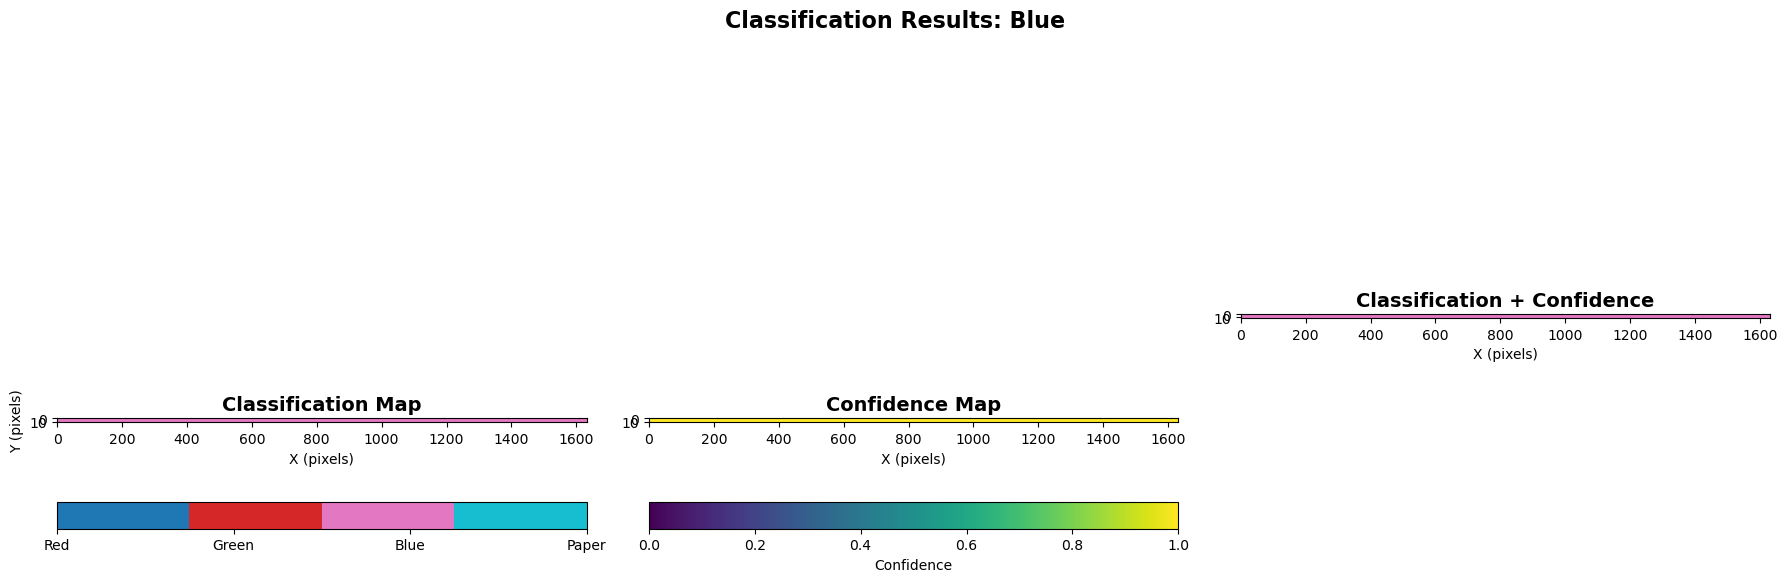

  ✓ Saved: inference_results\Blue\Blue_classification_only.png


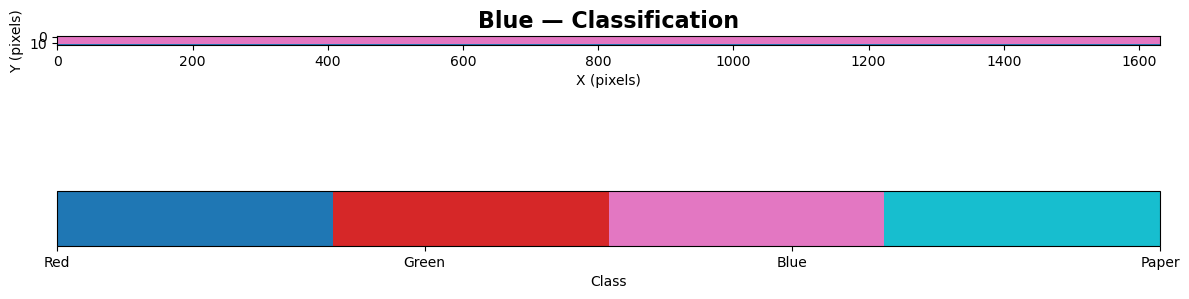

  ✓ Saved: inference_results\Blue\Blue_statistics.txt

[2/7] Green
  Extracting patches (size=3, stride=1)...
    → 17930 patches
  Running predictions (batch_size=8)...
  Classified pixels : 17930
  Avg confidence    : 1.0000
  Classes found     : 1
  ✓ Saved: inference_results\Green\Green_class_map.npy
  ✓ Saved: inference_results\Green\Green_confidence_map.npy
  ✓ Saved: inference_results\Green\Green_classification.png


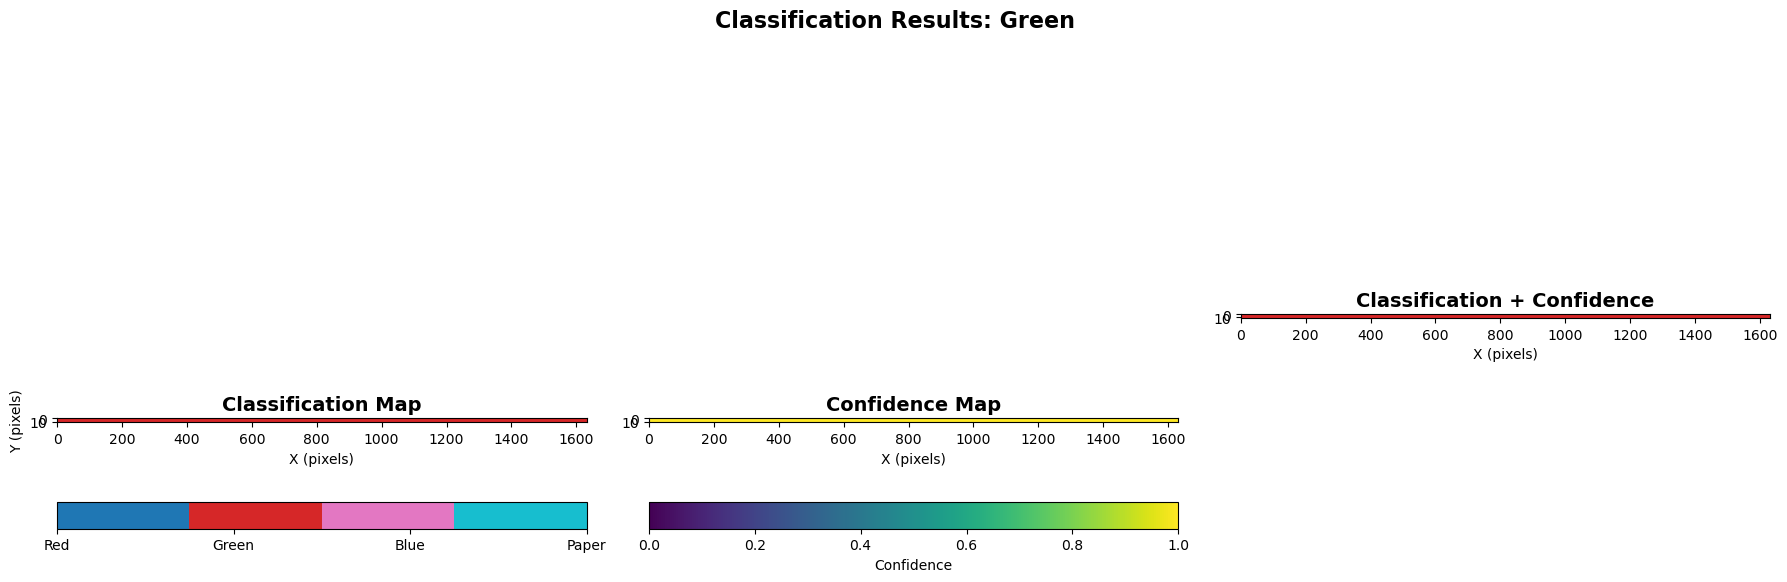

  ✓ Saved: inference_results\Green\Green_classification_only.png


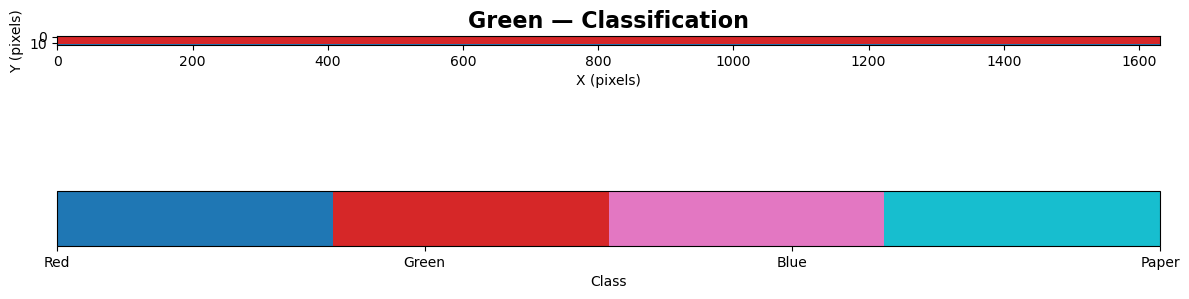

  ✓ Saved: inference_results\Green\Green_statistics.txt

[3/7] Paper
  Extracting patches (size=3, stride=1)...
    → 17930 patches
  Running predictions (batch_size=8)...
  Classified pixels : 17930
  Avg confidence    : 1.0000
  Classes found     : 1
  ✓ Saved: inference_results\Paper\Paper_class_map.npy
  ✓ Saved: inference_results\Paper\Paper_confidence_map.npy
  ✓ Saved: inference_results\Paper\Paper_classification.png


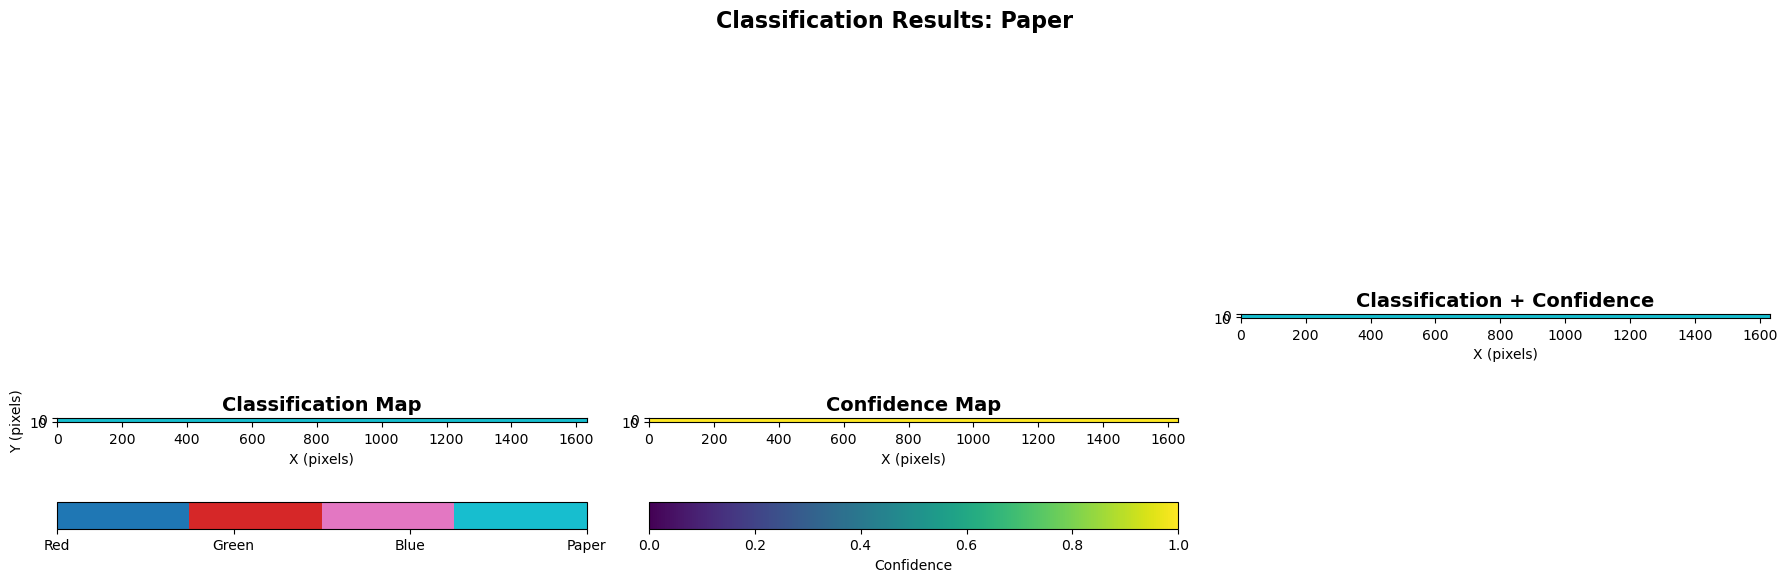

  ✓ Saved: inference_results\Paper\Paper_classification_only.png


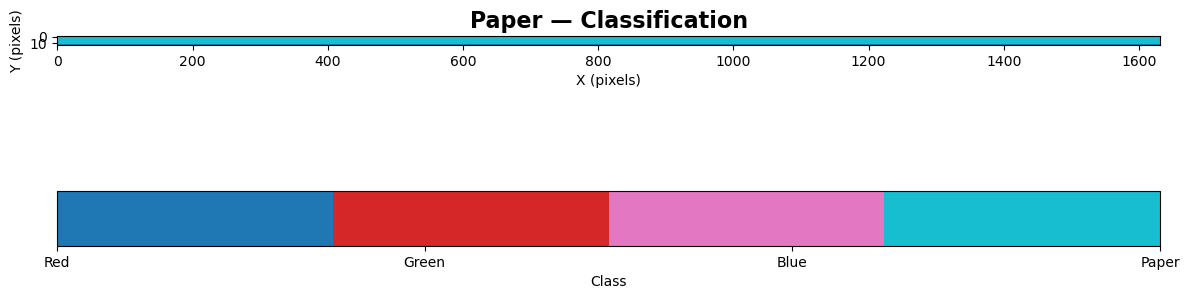

  ✓ Saved: inference_results\Paper\Paper_statistics.txt

[4/7] Red
  Extracting patches (size=3, stride=1)...
    → 17930 patches
  Running predictions (batch_size=8)...
  Classified pixels : 17930
  Avg confidence    : 1.0000
  Classes found     : 1
  ✓ Saved: inference_results\Red\Red_class_map.npy
  ✓ Saved: inference_results\Red\Red_confidence_map.npy
  ✓ Saved: inference_results\Red\Red_classification.png


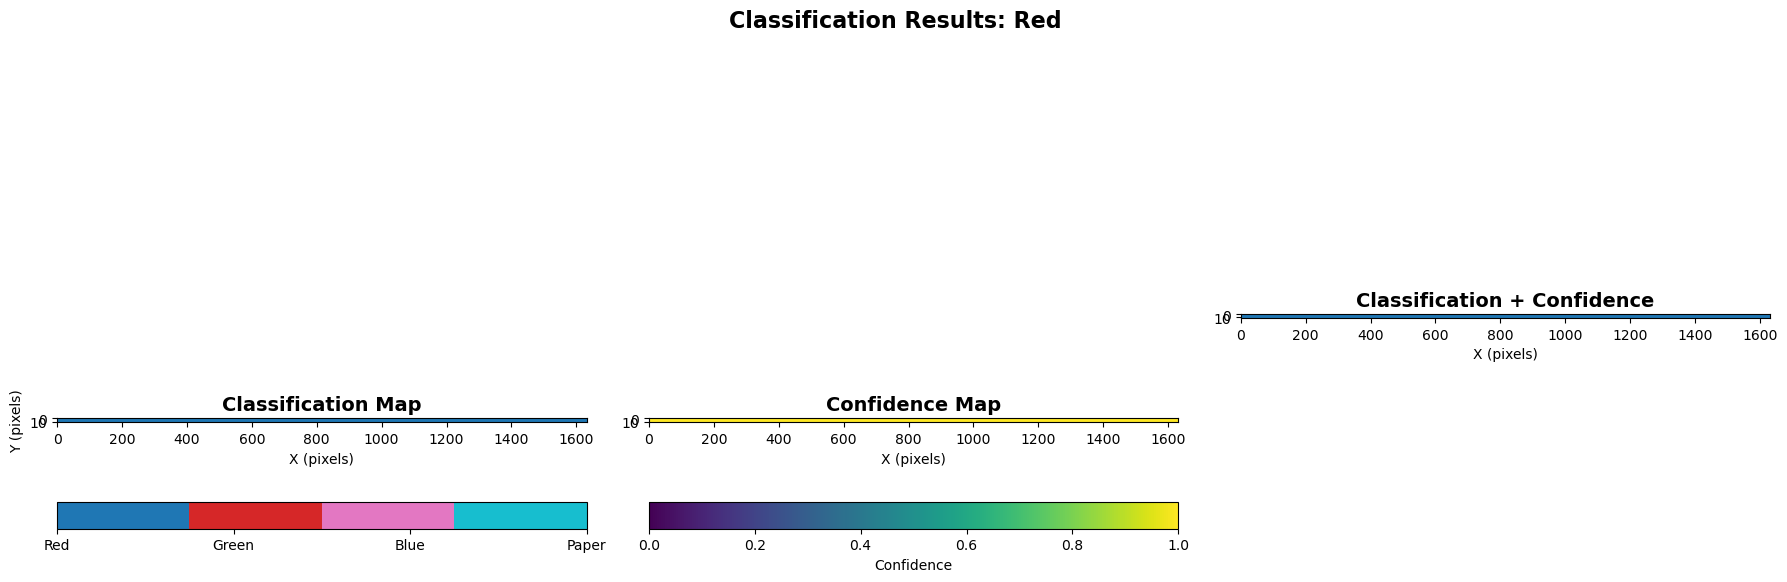

  ✓ Saved: inference_results\Red\Red_classification_only.png


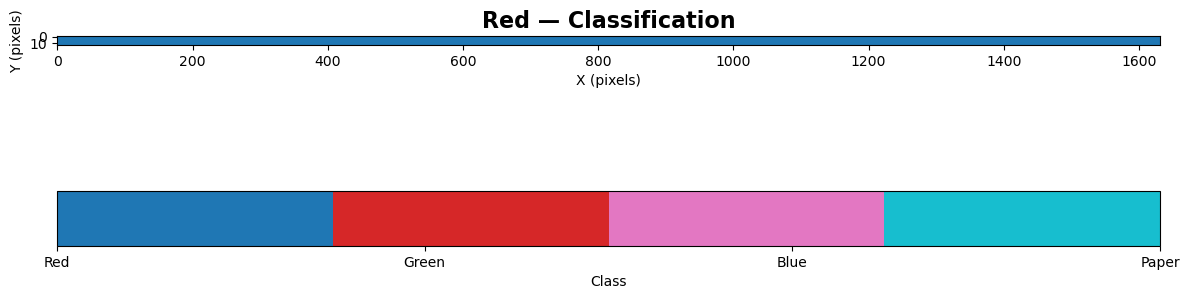

  ✓ Saved: inference_results\Red\Red_statistics.txt

[5/7] Spectrum-1
  Extracting patches (size=3, stride=1)...
    → 141810 patches
  Running predictions (batch_size=8)...
  Classified pixels : 141810
  Avg confidence    : 1.0000
  Classes found     : 1
  ✓ Saved: inference_results\Spectrum-1\Spectrum-1_class_map.npy
  ✓ Saved: inference_results\Spectrum-1\Spectrum-1_confidence_map.npy
  ✓ Saved: inference_results\Spectrum-1\Spectrum-1_classification.png


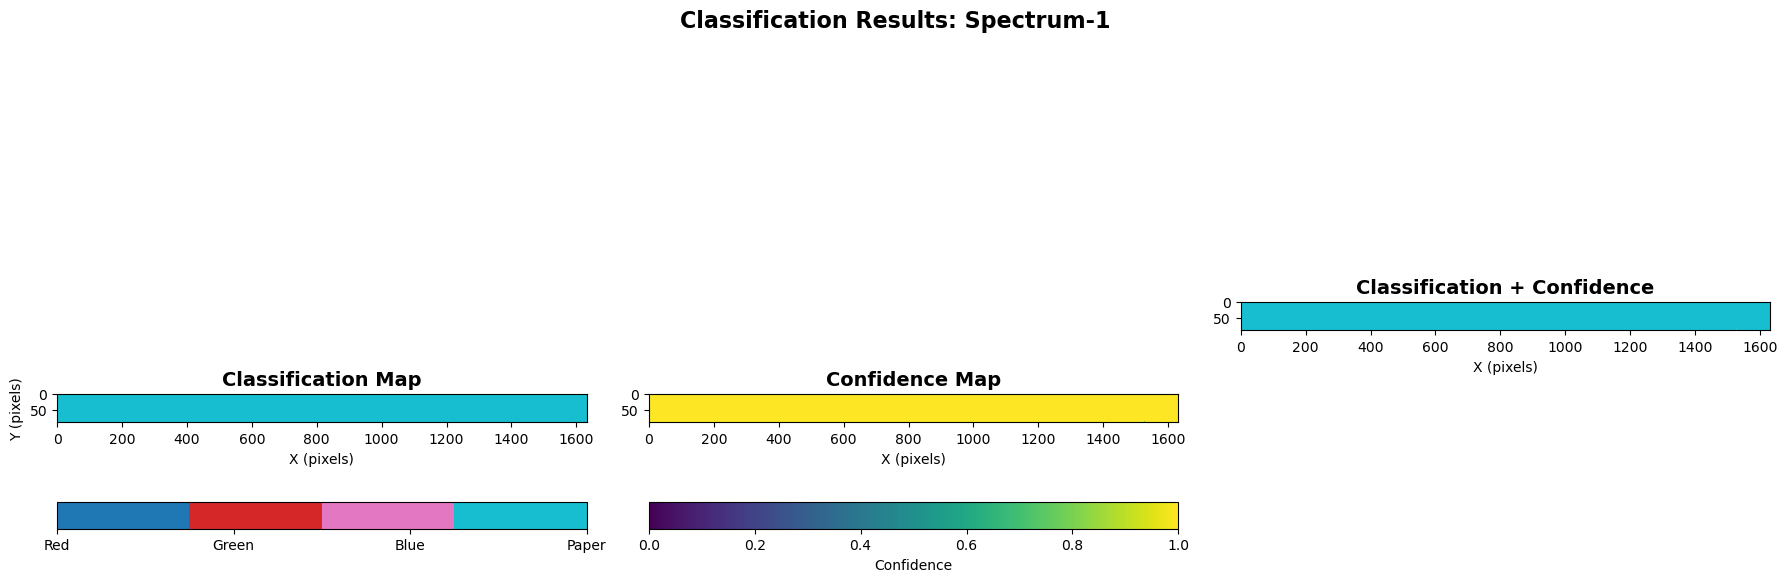

  ✓ Saved: inference_results\Spectrum-1\Spectrum-1_classification_only.png


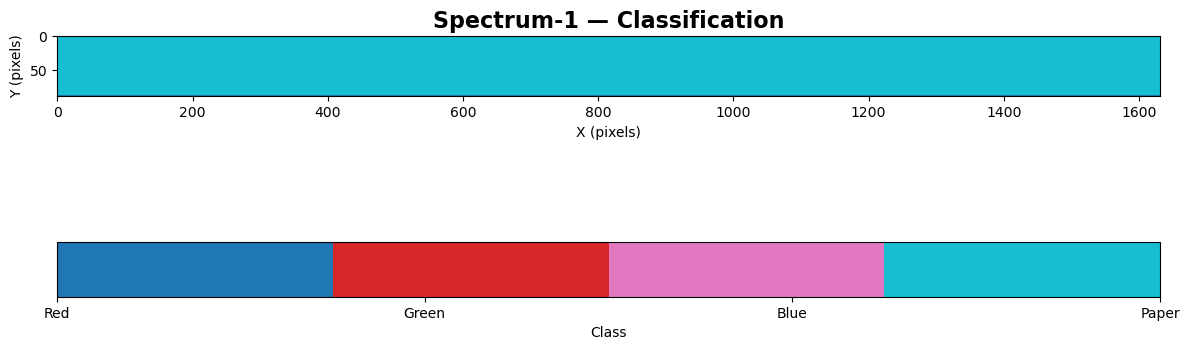

  ✓ Saved: inference_results\Spectrum-1\Spectrum-1_statistics.txt

[6/7] Spectrum-3
  Extracting patches (size=3, stride=1)...
    → 88020 patches
  Running predictions (batch_size=8)...
  Classified pixels : 88020
  Avg confidence    : 1.0000
  Classes found     : 1
  ✓ Saved: inference_results\Spectrum-3\Spectrum-3_class_map.npy
  ✓ Saved: inference_results\Spectrum-3\Spectrum-3_confidence_map.npy
  ✓ Saved: inference_results\Spectrum-3\Spectrum-3_classification.png


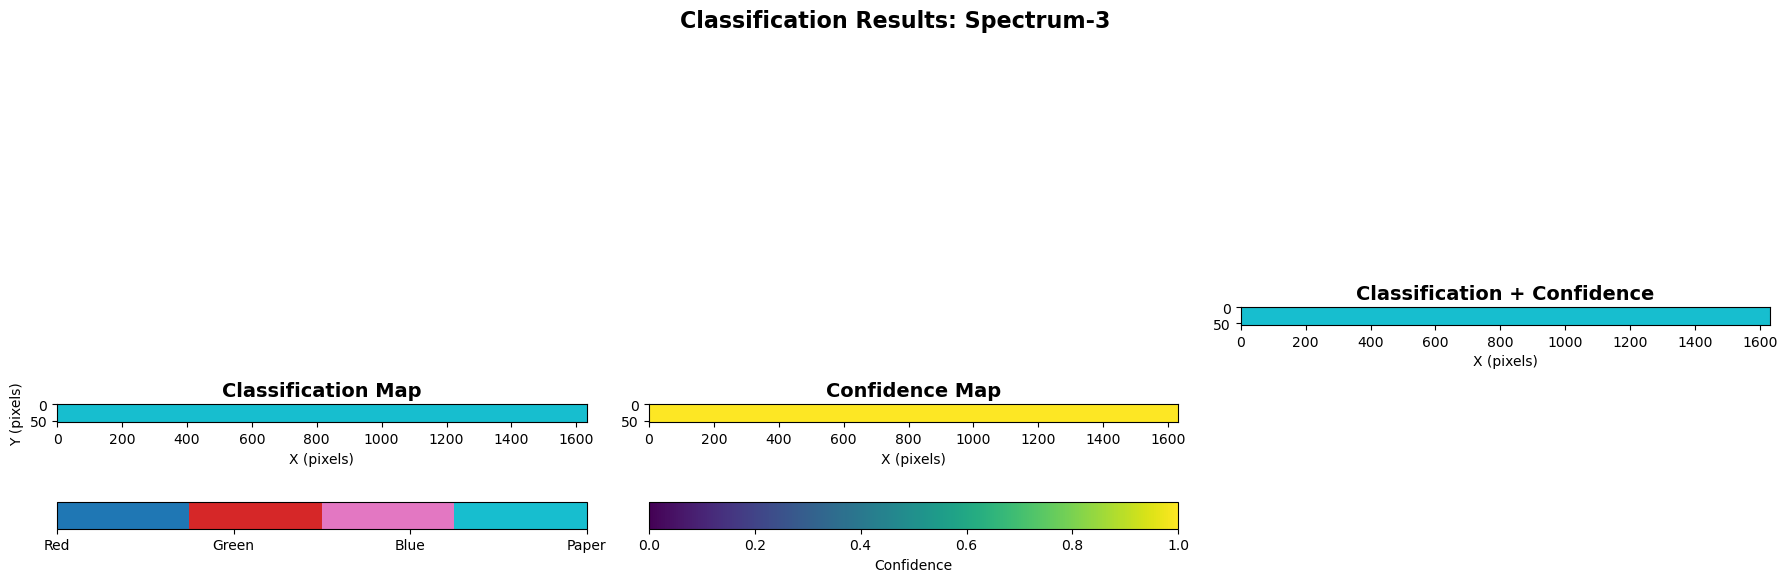

  ✓ Saved: inference_results\Spectrum-3\Spectrum-3_classification_only.png


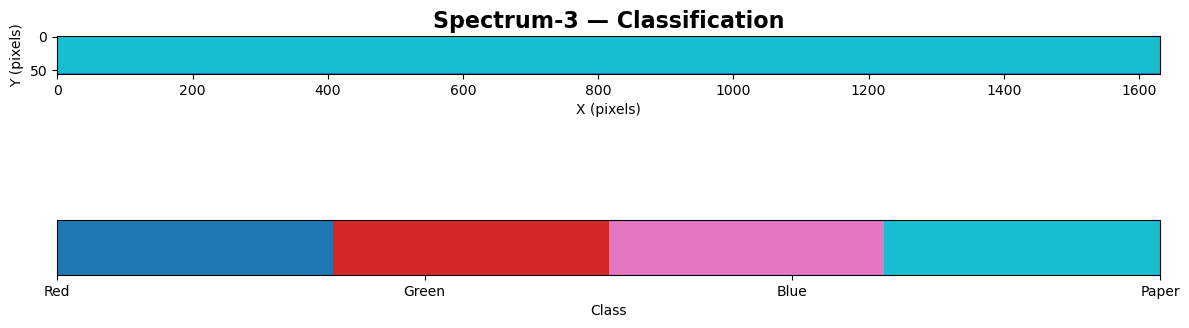

  ✓ Saved: inference_results\Spectrum-3\Spectrum-3_statistics.txt

[7/7] Spectrum-Simplified
  Extracting patches (size=3, stride=1)...
    → 176040 patches
  Running predictions (batch_size=8)...
  Classified pixels : 176040
  Avg confidence    : 0.9989
  Classes found     : 4
  ✓ Saved: inference_results\Spectrum-Simplified\Spectrum-Simplified_class_map.npy
  ✓ Saved: inference_results\Spectrum-Simplified\Spectrum-Simplified_confidence_map.npy
  ✓ Saved: inference_results\Spectrum-Simplified\Spectrum-Simplified_classification.png


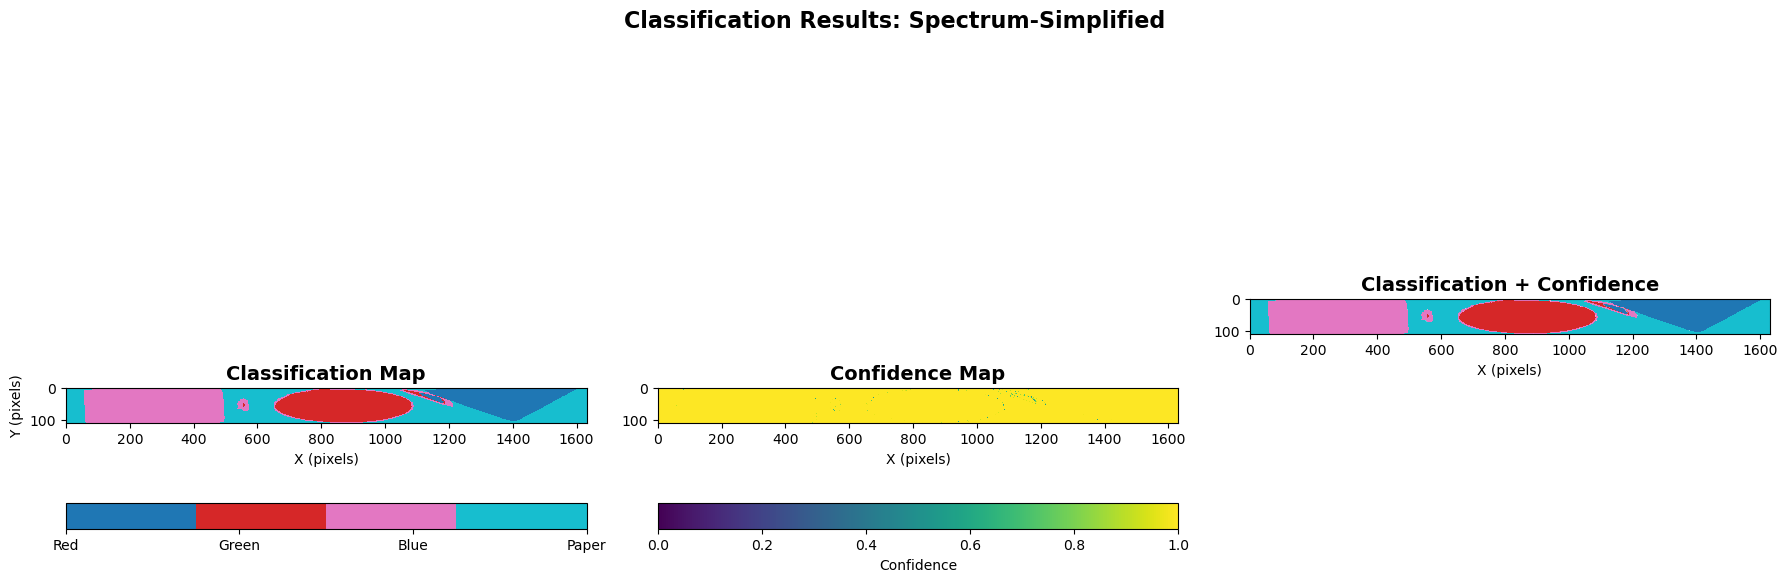

  ✓ Saved: inference_results\Spectrum-Simplified\Spectrum-Simplified_classification_only.png


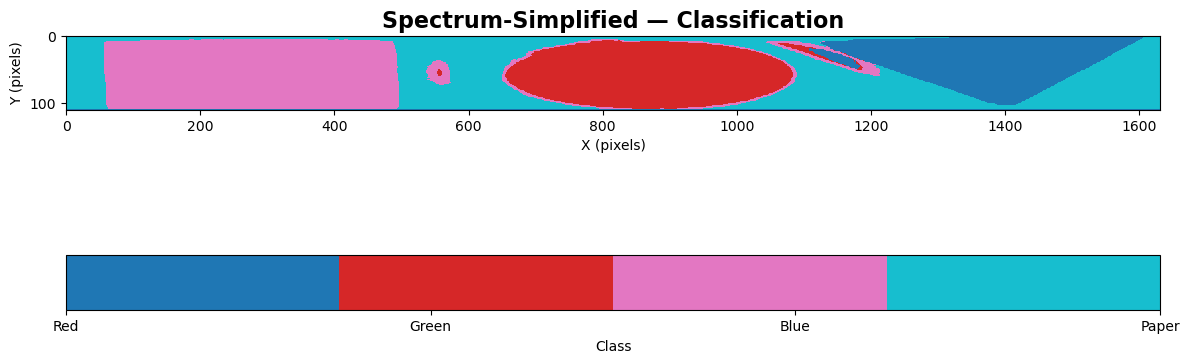

  ✓ Saved: inference_results\Spectrum-Simplified\Spectrum-Simplified_statistics.txt

Batch complete — 7 succeeded, 0 failed.


In [32]:
# ── Inference settings ───────────────────────────────────────────
INFERENCE_INPUT_DIR  = "hsi_datasets/v303"     # directory of .mat files to classify
INFERENCE_OUTPUT_DIR = "inference_results"     # where results are saved
CLASS_NAMES          = ["Red", "Green", "Blue", "Paper"]

# Collect all .mat files from the input directory
mat_files = sorted([
    os.path.join(INFERENCE_INPUT_DIR, f)
    for f in os.listdir(INFERENCE_INPUT_DIR)
    if f.endswith(".mat")
])
print(f"Files to classify: {len(mat_files)}")

# Load the engine once, reuse across all files
engine     = InferenceEngine(model_path=model_path, stride=config.stride,
                             normalize=config.normalize or "minmax")
engine.load_model()
visualizer = ResultVisualizer(class_names=CLASS_NAMES)

successful, failed = 0, 0

for i, mat_path in enumerate(mat_files, 1):
    dataset_name = os.path.splitext(os.path.basename(mat_path))[0]
    output_dir   = os.path.join(INFERENCE_OUTPUT_DIR, dataset_name)

    print(f"\n[{i}/{len(mat_files)}] {dataset_name}")
    print("=" * 50)

    try:
        class_map, confidence_map, predictions = engine.predict(mat_path)

        print(f"  Classified pixels : {int((class_map >= 0).sum())}")
        print(f"  Avg confidence    : {confidence_map[class_map >= 0].mean():.4f}")
        print(f"  Classes found     : {len(np.unique(class_map[class_map >= 0]))}")

        visualizer.save_all(
            class_map, confidence_map, predictions,
            dataset_name=dataset_name,
            output_dir=output_dir,
        )
        successful += 1

    except Exception as exc:
        print(f"  ❌ ERROR: {exc}")
        failed += 1

print(f"\nBatch complete — {successful} succeeded, {failed} failed.")

## Cell 13 — Result Viewer: Reload and Display Saved Maps

In [33]:
class ResultLoader:
    """
    Loads saved class_map and confidence_map .npy arrays from an inference
    output directory produced by InferenceEngine.

    Expected filenames
    ------------------
    <dataset_name>_class_map.npy
    <dataset_name>_confidence_map.npy

    Parameters
    ----------
    input_dir    : str        — Path to the inference output directory
    dataset_name : str | None — Explicit name; auto-detected from filenames if None
    """

    def __init__(self, input_dir: str, dataset_name: str | None = None):
        self.input_dir    = input_dir
        self.dataset_name = dataset_name or self._detect_name(input_dir)

    def load(self) -> tuple[np.ndarray, np.ndarray]:
        """Load and return (class_map, confidence_map)."""
        class_path = os.path.join(self.input_dir, f"{self.dataset_name}_class_map.npy")
        conf_path  = os.path.join(self.input_dir, f"{self.dataset_name}_confidence_map.npy")

        for p in (class_path, conf_path):
            if not os.path.exists(p):
                raise FileNotFoundError(f"Result file not found: {p}")

        class_map      = np.load(class_path)
        confidence_map = np.load(conf_path)

        print(f"Loaded '{self.dataset_name}'")
        print(f"  class_map      : {class_map.shape}, dtype={class_map.dtype}")
        print(f"  confidence_map : {confidence_map.shape}, dtype={confidence_map.dtype}")
        print(f"  Classified px  : {int((class_map >= 0).sum())}")
        print(f"  Unique classes : {np.unique(class_map[class_map >= 0]).tolist()}")
        return class_map, confidence_map

    @staticmethod
    def _detect_name(input_dir: str) -> str:
        suffix = "_class_map.npy"
        for f in os.listdir(input_dir):
            if f.endswith(suffix):
                return f[:-len(suffix)]
        return os.path.basename(input_dir.rstrip("/\\"))


class MapUpsampler:
    """
    Nearest-neighbour upsampling along the short (scan) axis — for display only.

    Intended for pushbroom datasets with very short scan axes (e.g. 13–110 lines).
    Returned arrays should NOT be saved back to disk.
    """

    @staticmethod
    def upsample(
        class_map      : np.ndarray,
        confidence_map : np.ndarray,
        min_height     : int = 300,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Upsample both maps along the short axis so it reaches at least min_height.

        Returns upsampled copies — originals are unchanged.
        """
        H, W      = class_map.shape
        short_ax  = 0 if H <= W else 1
        short_dim = H if short_ax == 0 else W

        if short_dim >= min_height:
            print(f"  Short axis ({short_dim}px) ≥ min_height ({min_height}px) — no upsampling.")
            return class_map, confidence_map

        scale = int(np.ceil(min_height / short_dim))

        if short_ax == 0:
            class_up = np.repeat(class_map,      scale, axis=0)
            conf_up  = np.repeat(confidence_map, scale, axis=0)
        else:
            class_up = np.repeat(class_map,      scale, axis=1)
            conf_up  = np.repeat(confidence_map, scale, axis=1)

        print(f"  Upsampled: {class_map.shape} → {class_up.shape} (×{scale} on axis {short_ax})")
        print("  ⚠  Display only — upsampled arrays are NOT saved to disk.")
        return class_up, conf_up


class ResultViewer:
    """
    Renders inline figures (class map and/or confidence map) in Jupyter.

    Colourmap is semantic where possible:
        Names containing 'red'   → #d62728
        Names containing 'green' → #2ca02c
        Names containing 'blue'  → #1f77b4
        Names containing 'paper' → #cccccc
        All others               → tab10 fallback

    Parameters
    ----------
    class_names : list[str] — Ordered class label list
    max_fig_dim : float     — Longest figure dimension in inches (default 16)
    """

    _SEMANTIC_COLORS = {
        "red":   "#d62728",
        "green": "#2ca02c",
        "blue":  "#1f77b4",
        "paper": "#cccccc",
    }

    def __init__(self, class_names: list[str], max_fig_dim: float = 16.0):
        self.class_names = class_names
        self.max_fig_dim = max_fig_dim
        self._cmap_cls   = self._build_class_cmap(class_names)

    def show(
        self,
        class_map      : np.ndarray,
        confidence_map : np.ndarray,
        title          : str = "",
        show           : str = "both",
    ) -> None:
        """
        Display the figure inline.

        Parameters
        ----------
        show : 'both' | 'class' | 'confidence'
        """
        if show not in ("both", "class", "confidence"):
            raise ValueError(f"show must be 'both', 'class', or 'confidence' — got '{show}'")

        show_cls  = show in ("both", "class")
        show_conf = show in ("both", "confidence")
        n_panels  = 2 if show == "both" else 1

        H, W    = class_map.shape
        figsize = self._compute_figsize(H, W, n_panels)
        fig, axes = plt.subplots(1, n_panels, figsize=figsize)
        if n_panels == 1:
            axes = [axes]
        ax_iter = iter(axes)

        if show_cls:
            ax = next(ax_iter)
            n_classes = len(self.class_names)
            im1 = ax.imshow(class_map, cmap=self._cmap_cls,
                            vmin=0, vmax=n_classes - 1,
                            interpolation="nearest", aspect="auto")
            ax.set_title("Classification Map", fontsize=12, fontweight="bold")
            ax.set_xlabel("X (pixels)")
            ax.set_ylabel("Y (scan lines)")
            cbar1 = plt.colorbar(im1, ax=ax, ticks=range(n_classes), orientation="horizontal")
            cbar1.ax.set_xticklabels(self.class_names, rotation=15, ha="right")

        if show_conf:
            ax = next(ax_iter)
            im2 = ax.imshow(confidence_map, cmap="viridis",
                            vmin=0, vmax=1,
                            interpolation="nearest", aspect="auto")
            ax.set_title("Confidence Map", fontsize=12, fontweight="bold")
            ax.set_xlabel("X (pixels)")
            ax.set_ylabel("Y (scan lines)")
            plt.colorbar(im2, ax=ax, label="Confidence", orientation="horizontal")

        classified = int((class_map >= 0).sum())
        avg_conf   = float(confidence_map[class_map >= 0].mean()) if classified > 0 else 0.0
        unique_cls = np.unique(class_map[class_map >= 0])
        stats_text = (
            f"Shape: {H}×{W}  |  Classified: {classified}  |  "
            f"Avg conf: {avg_conf:.4f}  |  Classes: {len(unique_cls)}"
        )
        fig.suptitle(f"{title}  —  {stats_text}" if title else stats_text, fontsize=10)
        plt.tight_layout()
        plt.show()

    @classmethod
    def _build_class_cmap(cls, class_names: list[str]) -> mcolors.ListedColormap:
        tab10_iter = iter(plt.cm.tab10.colors)
        colours    = []
        for name in class_names:
            lower   = name.lower()
            matched = next(
                (hex_c for kw, hex_c in cls._SEMANTIC_COLORS.items() if kw in lower),
                None,
            )
            colours.append(matched if matched else next(tab10_iter, "#888888"))
        return mcolors.ListedColormap(colours)

    def _compute_figsize(self, H: int, W: int, n_panels: int) -> tuple[float, float]:
        """Compute figsize that respects the map's aspect ratio."""
        panel_w = self.max_fig_dim / n_panels
        panel_h = max(panel_w * (H / W), 1.5)
        return panel_w * n_panels, panel_h + 1.5

## Cell 14 — Display Saved Results

Found 7 result(s) in 'inference_results'.

[1/7] Blue
Loaded 'Blue'
  class_map      : (13, 1632), dtype=int32
  confidence_map : (13, 1632), dtype=float32
  Classified px  : 17930
  Unique classes : [2]
  Upsampled: (13, 1632) → (312, 1632) (×24 on axis 0)
  ⚠  Display only — upsampled arrays are NOT saved to disk.


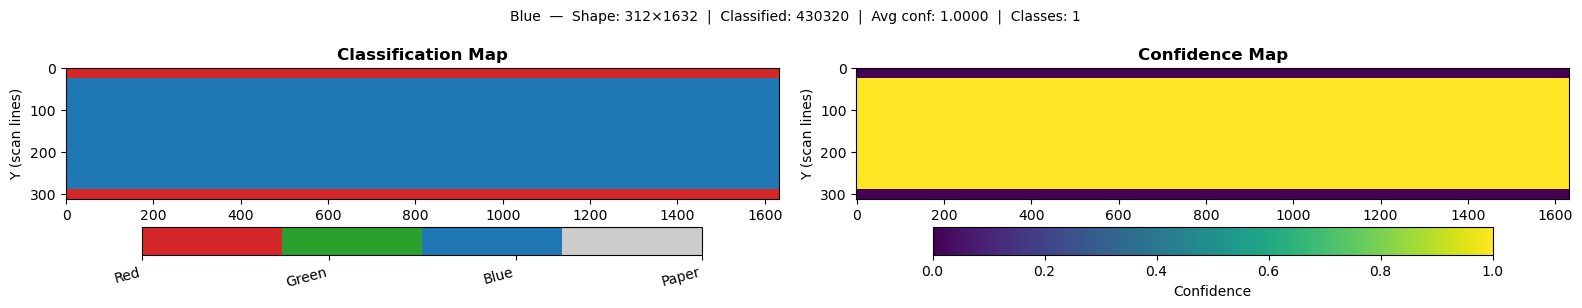

[2/7] Green
Loaded 'Green'
  class_map      : (13, 1632), dtype=int32
  confidence_map : (13, 1632), dtype=float32
  Classified px  : 17930
  Unique classes : [1]
  Upsampled: (13, 1632) → (312, 1632) (×24 on axis 0)
  ⚠  Display only — upsampled arrays are NOT saved to disk.


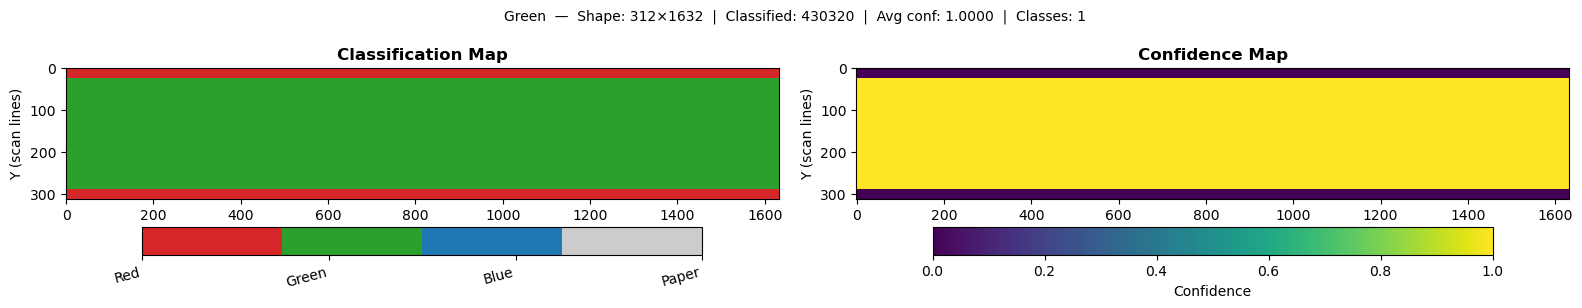

[3/7] Paper
Loaded 'Paper'
  class_map      : (13, 1632), dtype=int32
  confidence_map : (13, 1632), dtype=float32
  Classified px  : 17930
  Unique classes : [3]
  Upsampled: (13, 1632) → (312, 1632) (×24 on axis 0)
  ⚠  Display only — upsampled arrays are NOT saved to disk.


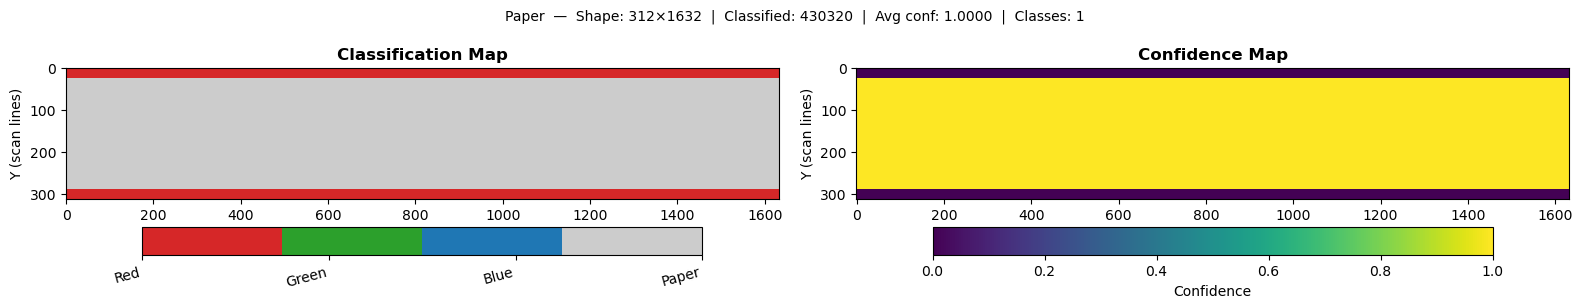

[4/7] Red
Loaded 'Red'
  class_map      : (13, 1632), dtype=int32
  confidence_map : (13, 1632), dtype=float32
  Classified px  : 17930
  Unique classes : [0]
  Upsampled: (13, 1632) → (312, 1632) (×24 on axis 0)
  ⚠  Display only — upsampled arrays are NOT saved to disk.


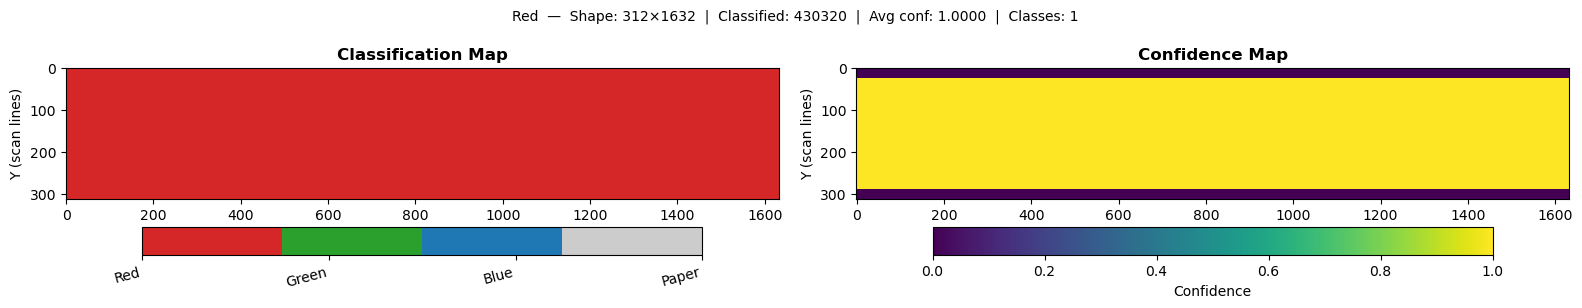

[5/7] Spectrum-1
Loaded 'Spectrum-1'
  class_map      : (89, 1632), dtype=int32
  confidence_map : (89, 1632), dtype=float32
  Classified px  : 141810
  Unique classes : [3]
  Upsampled: (89, 1632) → (356, 1632) (×4 on axis 0)
  ⚠  Display only — upsampled arrays are NOT saved to disk.


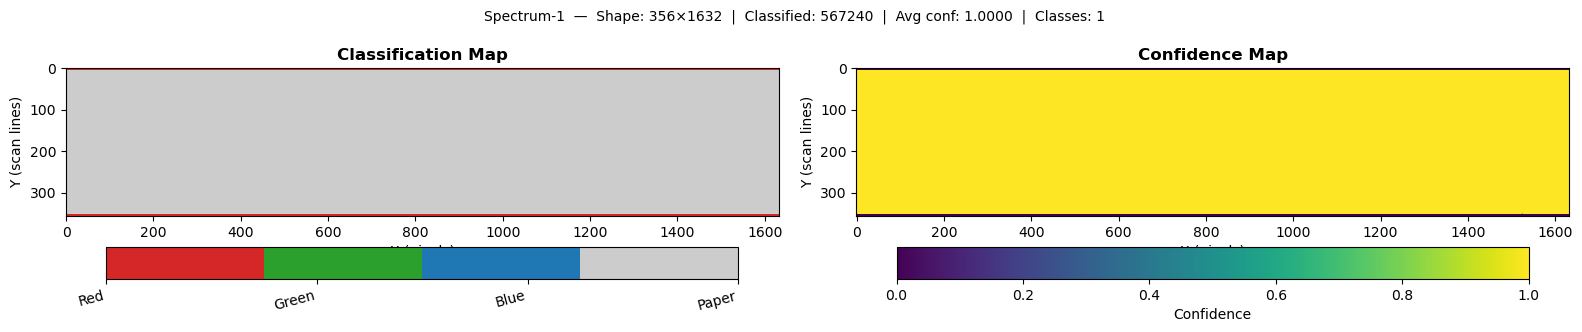

[6/7] Spectrum-3
Loaded 'Spectrum-3'
  class_map      : (56, 1632), dtype=int32
  confidence_map : (56, 1632), dtype=float32
  Classified px  : 88020
  Unique classes : [3]
  Upsampled: (56, 1632) → (336, 1632) (×6 on axis 0)
  ⚠  Display only — upsampled arrays are NOT saved to disk.


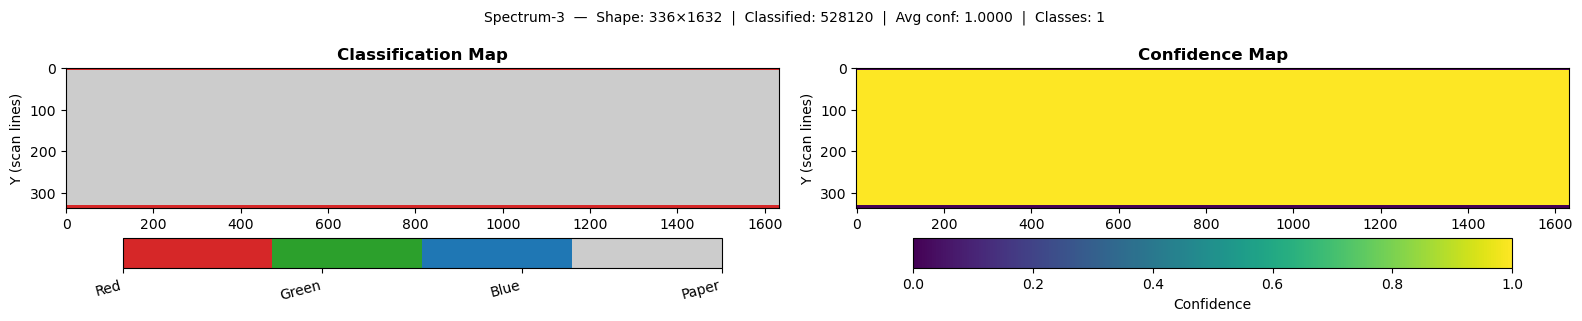

[7/7] Spectrum-Simplified
Loaded 'Spectrum-Simplified'
  class_map      : (110, 1632), dtype=int32
  confidence_map : (110, 1632), dtype=float32
  Classified px  : 176040
  Unique classes : [0, 1, 2, 3]
  Upsampled: (110, 1632) → (330, 1632) (×3 on axis 0)
  ⚠  Display only — upsampled arrays are NOT saved to disk.


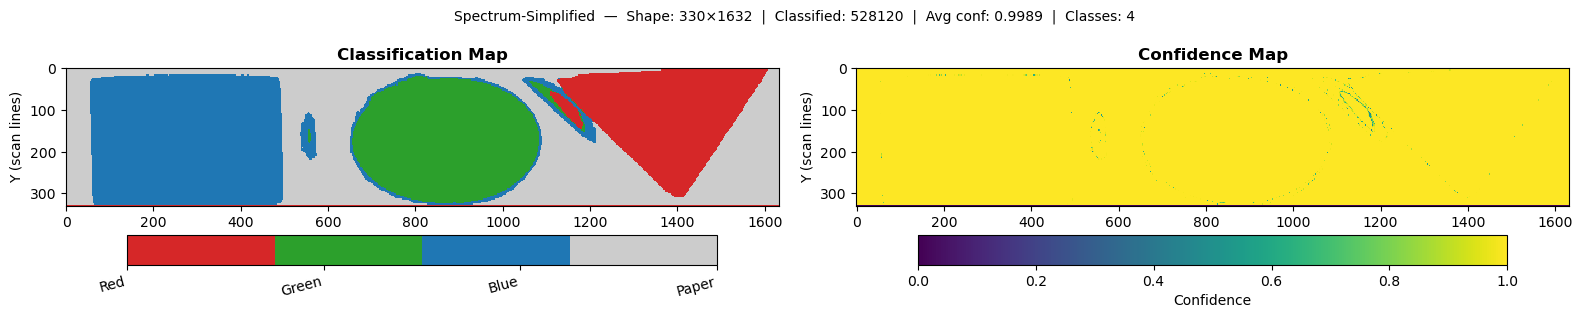

In [34]:
# ── Viewer settings ──────────────────────────────────────────────
UPSAMPLE    = True    # nearest-neighbour upsample along short axis for display
MIN_HEIGHT  = 300     # minimum short-axis pixels after upsampling
SHOW        = "both"  # 'both' | 'class' | 'confidence'

viewer = ResultViewer(class_names=CLASS_NAMES)

# Collect all result subdirectories
result_dirs = sorted([
    os.path.join(INFERENCE_OUTPUT_DIR, d)
    for d in os.listdir(INFERENCE_OUTPUT_DIR)
    if os.path.isdir(os.path.join(INFERENCE_OUTPUT_DIR, d))
    and any(f.endswith("_class_map.npy")
            for f in os.listdir(os.path.join(INFERENCE_OUTPUT_DIR, d)))
])

print(f"Found {len(result_dirs)} result(s) in '{INFERENCE_OUTPUT_DIR}'.\n")

for i, result_dir in enumerate(result_dirs, 1):
    print(f"[{i}/{len(result_dirs)}] {os.path.basename(result_dir)}")
    try:
        loader = ResultLoader(result_dir)
        class_map, confidence_map = loader.load()

        if UPSAMPLE:
            class_map, confidence_map = MapUpsampler.upsample(
                class_map, confidence_map, min_height=MIN_HEIGHT
            )

        viewer.show(class_map, confidence_map, title=loader.dataset_name, show=SHOW)

    except Exception as exc:
        print(f"  ❌ ERROR: {exc}")